In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("movie_reviews.csv")

In [5]:
df.head(50)

,movie,review
0,scary_movie_2026,Storyline was far from flowing and logical. De...
1,scary_movie_2026,Leave at the middle
2,scary_movie_2026,"20 minutes in, I already started hating the mo..."
3,scary_movie_2026,"Hilarious, they did a great job with this. Def..."
4,scary_movie_2026,It wasnt as funny as the others. I liked seein...
5,scary_movie_2026,Joke weren’t that funny
6,scary_movie_2026,"It was funny, the nostalgia was there. not as ..."
7,scary_movie_2026,This movie was great! I just wish that there w...
8,scary_movie_2026,Omg it's so bad. Didn't laugh once. And I'm a ...
9,scary_movie_2026,Had some laughs but some jokes didn’t land . W...


In [6]:
# remove duplicated reviews by checking the "review" column
df.drop_duplicates(subset="review", inplace=True)

In [7]:
df.shape

(301, 2)

In [8]:
df.to_csv("pre-processed_movie_reviews.csv", index=False)

In [9]:
df.shape

(301, 2)

# Data Cleaning

In [10]:
import re

In [11]:
def clean_text(text):

    text = str(text).lower()  # Convert to lowercase

    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation

    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)  # Remove URLs

    text = re.sub(r'\d+', '', text)  # Remove numbers

    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace

    text = re.sub(r'[^\x00-\x7F]+', '', text) # Remove non-ASCII characters

    return text.strip()

df['cleaned_review'] = df['review'].apply(clean_text)

In [12]:
df.head()

,movie,review,cleaned_review
0,scary_movie_2026,Storyline was far from flowing and logical. De...,storyline was far from flowing and logical def...
1,scary_movie_2026,Leave at the middle,leave at the middle
2,scary_movie_2026,"20 minutes in, I already started hating the mo...",minutes in i already started hating the movie ...
3,scary_movie_2026,"Hilarious, they did a great job with this. Def...",hilarious they did a great job with this defin...
4,scary_movie_2026,It wasnt as funny as the others. I liked seein...,it wasnt as funny as the others i liked seeing...


# Genarate labels

In [13]:
from textblob import TextBlob

In [14]:
def sentiment_label(text):

    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral'
    
df['sentiment'] = df['cleaned_review'].apply(sentiment_label)

In [15]:
df.head()

,movie,review,cleaned_review,sentiment
0,scary_movie_2026,Storyline was far from flowing and logical. De...,storyline was far from flowing and logical def...,positive
1,scary_movie_2026,Leave at the middle,leave at the middle,neutral
2,scary_movie_2026,"20 minutes in, I already started hating the mo...",minutes in i already started hating the movie ...,negative
3,scary_movie_2026,"Hilarious, they did a great job with this. Def...",hilarious they did a great job with this defin...,positive
4,scary_movie_2026,It wasnt as funny as the others. I liked seein...,it wasnt as funny as the others i liked seeing...,positive


# Explonatary Data Analysis

In [16]:
from collections import Counter

In [19]:
words = " ".join(df["cleaned_review"]).split()
Counter(words).most_common(10)

[('the', 608),
 ('and', 352),
 ('a', 343),
 ('of', 222),
 ('it', 217),
 ('to', 209),
 ('i', 201),
 ('movie', 179),
 ('was', 167),
 ('is', 142)]

## Word Cloud

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

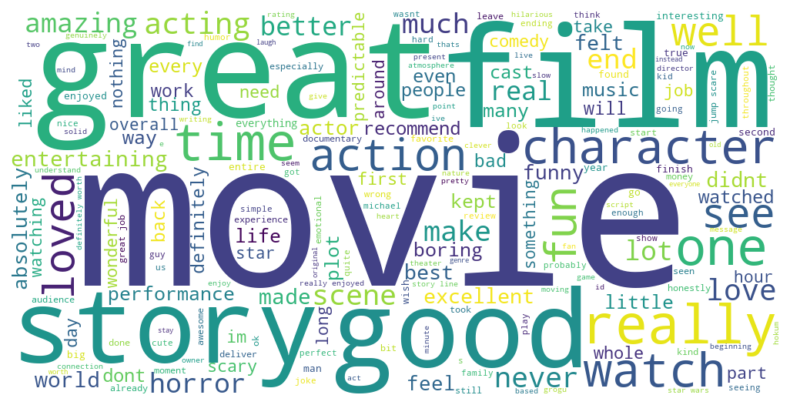

In [24]:
wordcloud = WordCloud(
    width=1000, 
    height=500, 
    background_color='white').generate(" ".join(df["cleaned_review"]))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()